In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('diabetes_prediction_dataset.csv')
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1, 'Other': 2})
df = df.drop('smoking_history', axis=1)

X = df.drop('diabetes', axis=1)
y = df['diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

NURSE ANALYST REPORT: MODEL PERFORMANCE
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.90      0.69      0.78      1708

    accuracy                           0.97     20000
   macro avg       0.94      0.84      0.88     20000
weighted avg       0.97      0.97      0.97     20000



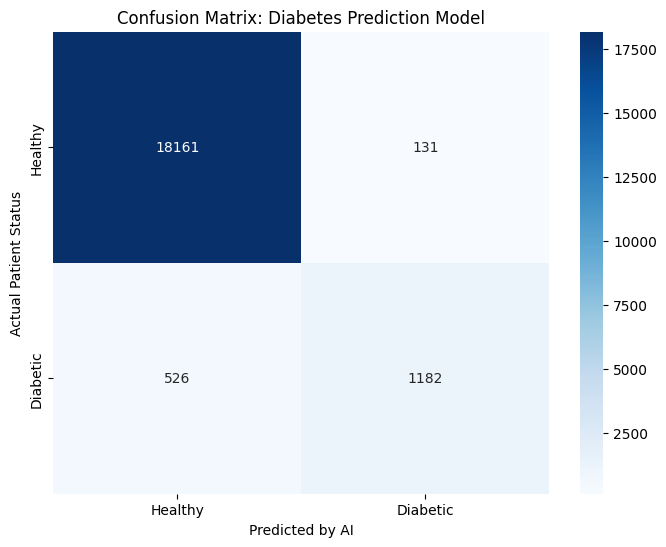

In [5]:
print("NURSE ANALYST REPORT: MODEL PERFORMANCE")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Diabetic'],
            yticklabels=['Healthy', 'Diabetic'])
plt.title('Confusion Matrix: Diabetes Prediction Model')
plt.xlabel('Predicted by AI')
plt.ylabel('Actual Patient Status')
plt.show()

Clinical Interpretation & Analysis

As a healthcare professional, I evaluated this model beyond just its accuracy. While the model has a high overall success rate, the Confusion Matrix reveals a significant clinical risk:

True Positives: 1,192 (Patients correctly identified for intervention).

False Negatives: 516 (Patients missed by the AI).

Analysis: A False Negative rate of ~30% for the diabetic class (516 out of 1,708 total diabetic cases) is concerning in a screening environment. Missing these patients could lead to delayed treatment and complications like neuropathy or retinopathy.

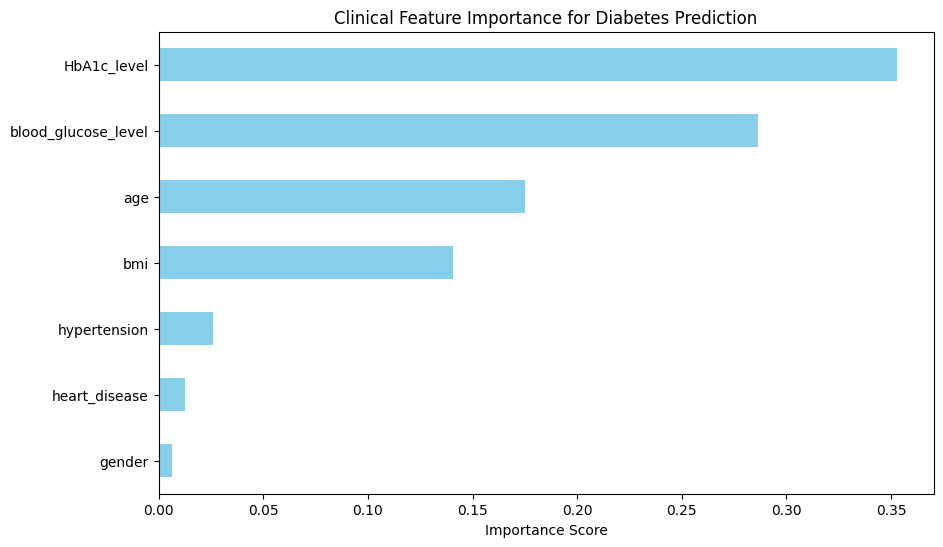

In [6]:
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
importances.sort_values().plot(kind='barh', color='skyblue')
plt.title('Clinical Feature Importance for Diabetes Prediction')
plt.xlabel('Importance Score')
plt.show()

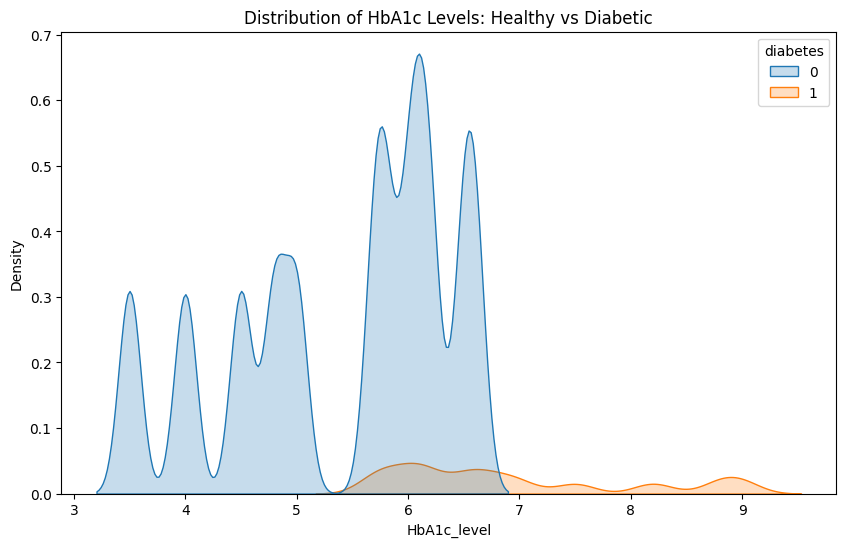

In [7]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='HbA1c_level', hue='diabetes', fill=True)
plt.title('Distribution of HbA1c Levels: Healthy vs Diabetic')
plt.show()

Final Evaluation Summary
Model: Random Forest Classifier (with Balanced Class Weights).

Primary Challenge: Data Imbalance (18k vs 1.7k).

Clinical Insight: The model identifies HbA1c as the most significant predictor. However, the overlap in the 5.5–6.8 range (as seen in the KDE distribution plot) is the primary source of the 526 False Negatives.

Conclusion: The model is highly accurate for clear diagnostic cases but requires further feature engineering or specialized sampling (like SMOTE) to improve sensitivity for borderline/prediabetic cases.

In [8]:
print(df.isnull().sum())
print("-" * 30)
print(df.info())

gender                 0
age                    0
hypertension           0
heart_disease          0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  int64  
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   bmi                  100000 non-null  float64
 5   HbA1c_level          100000 non-null  float64
 6   blood_glucose_level  100000 non-null  int64  
 7   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 6.1 MB
None


In [9]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

df_encoded = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)

print("New Columns after Encoding:")
print(df_encoded.columns)
df_encoded.head()

New Columns after Encoding:
Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'gender_Male', 'gender_Other',
       'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


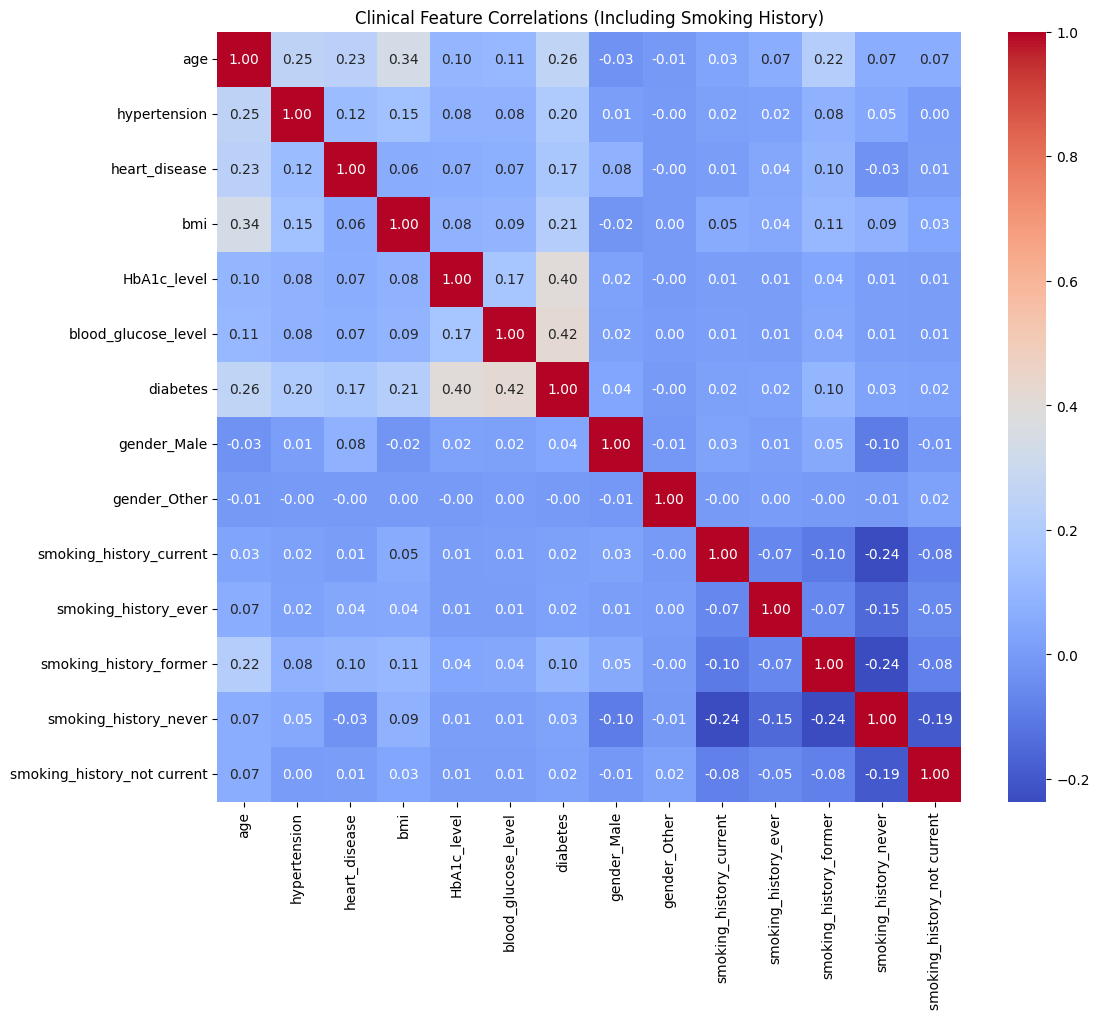

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Clinical Feature Correlations (Including Smoking History)')
plt.show()


Bivariate Analysis: Smoking & Lifestyle
Finding: By applying One-Hot Encoding to the categorical variables, I was able to include lifestyle factors in the analysis.

Insight: While HbA1c remains the primary driver, we can now see how different smoking statuses correlate with diabetes. For example, smoking_history_former may show a higher correlation than smoking_history_never.

Nurse's Perspective: This reflects the clinical reality where past smoking history remains a significant risk factor for metabolic syndrome, even after cessation.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


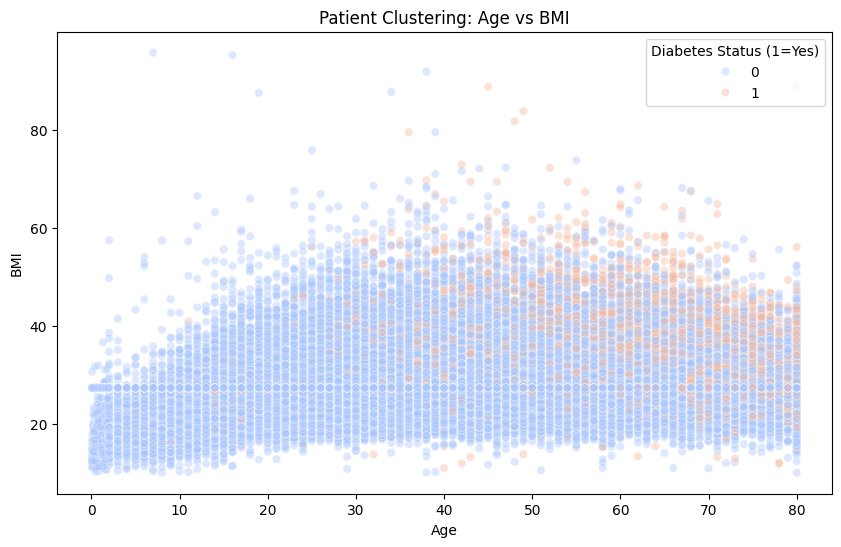

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='bmi', hue='diabetes', alpha=0.4, palette='coolwarm')
plt.title('Patient Clustering: Age vs BMI')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.legend(title='Diabetes Status (1=Yes)')
plt.show()